# In-Hospital Mortality Prediction on SUPPORT2

This notebook builds a full ML pipeline to predict **in-hospital mortality (`hospdead`)** on the SUPPORT2 dataset:

- Load and inspect the data  
- Perform basic EDA (with several plots)  
- Feature selection with clinical and leakage considerations  
- Preprocessing with **XGBoost-based IterativeImputer + scaling + one-hot**  
- Stratified Train / Validation / Test split (60 / 20 / 20)  
- Train & tune 5 models with **class imbalance handling**  
- Evaluate on **validation and test**  
- Basic interpretability via feature importances / coefficients


In [2]:
# If running in Google Colab, uncomment this cell to install dependencies
!pip install ucimlrepo xgboost

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from xgboost import XGBRegressor

import warnings
import os

warnings.filterwarnings("ignore")
os.environ['XGBOOST_ENABLE_SYSTEM_LOG'] = '0'

sns.set(style='whitegrid')
print('Imports done.')

Imports done.


In [4]:
# Load SUPPORT2 dataset from UCI
support2 = fetch_ucirepo(id=880)

# Use the original dataframe so we keep all columns (including targets)
df = support2.data.original.copy()
print("SUPPORT2 dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:", df.columns.tolist())
print("\nTarget columns from metadata:", support2.metadata.get('target_col'))

SUPPORT2 dataset loaded successfully!
Shape: (9105, 48)

Columns: ['id', 'age', 'death', 'sex', 'hospdead', 'slos', 'd.time', 'dzgroup', 'dzclass', 'num.co', 'edu', 'income', 'scoma', 'charges', 'totcst', 'totmcst', 'avtisst', 'race', 'sps', 'aps', 'surv2m', 'surv6m', 'hday', 'diabetes', 'dementia', 'ca', 'prg2m', 'prg6m', 'dnr', 'dnrday', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls', 'sfdm2', 'adlsc']

Target columns from metadata: ['death', 'hospdead', 'sfdm2']


In [5]:
# Inspect basic structure
print('\n--- Data Overview ---')
print(df.info())

# Define target: in-hospital mortality
target_col = 'hospdead'
y = df[target_col].astype(int)

print('\nOutcome distribution (hospdead):')
print(y.value_counts(normalize=True).rename('proportion'))


--- Data Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 48 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        9105 non-null   int64  
 1   age       9105 non-null   float64
 2   death     9105 non-null   int64  
 3   sex       9105 non-null   object 
 4   hospdead  9105 non-null   int64  
 5   slos      9105 non-null   int64  
 6   d.time    9105 non-null   int64  
 7   dzgroup   9105 non-null   object 
 8   dzclass   9105 non-null   object 
 9   num.co    9105 non-null   int64  
 10  edu       7471 non-null   float64
 11  income    6123 non-null   object 
 12  scoma     9104 non-null   float64
 13  charges   8933 non-null   float64
 14  totcst    8217 non-null   float64
 15  totmcst   5630 non-null   float64
 16  avtisst   9023 non-null   float64
 17  race      9063 non-null   object 
 18  sps       9104 non-null   float64
 19  aps       9104 non-null   float64
 20  surv2m 

In [6]:
# We construct X by dropping:
# - Explicit targets and closely related outcomes
# - Strongly post-outcome / future information
# - IDs and highly derived cost fields

leak_or_nonfeature_cols = [
    'id',          # identifier
    'death',       # ultimate vital status
    'hospdead',    # target
    'surv2m',      # future survival info
    'surv6m',
    'prg2m',       # prognosis variables
    'prg6m',
    'd.time',      # time to death
    'sfdm2',       # 2-month functional status (survey; many missing)
    'slos',        # study length of stay
    'charges',     # economic outcome
    'totcst',
    'totmcst',
    'adlp',
    'adls',
    'dnr',
    'adlsc'
]

existing_to_drop = [c for c in leak_or_nonfeature_cols if c in df.columns]
X = df.drop(columns=existing_to_drop)

print('Dropped columns:', existing_to_drop)
print('Resulting feature matrix shape:', X.shape)

Dropped columns: ['id', 'death', 'hospdead', 'surv2m', 'surv6m', 'prg2m', 'prg6m', 'd.time', 'sfdm2', 'slos', 'charges', 'totcst', 'totmcst', 'adlp', 'adls', 'dnr', 'adlsc']
Resulting feature matrix shape: (9105, 31)


In [7]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print('Numeric columns (n={}):'.format(len(numeric_cols)))
print(numeric_cols)
print('\nCategorical columns (n={}):'.format(len(categorical_cols)))
print(categorical_cols)

Numeric columns (n=25):
['age', 'num.co', 'edu', 'scoma', 'avtisst', 'sps', 'aps', 'hday', 'diabetes', 'dementia', 'dnrday', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine']

Categorical columns (n=6):
['sex', 'dzgroup', 'dzclass', 'income', 'race', 'ca']


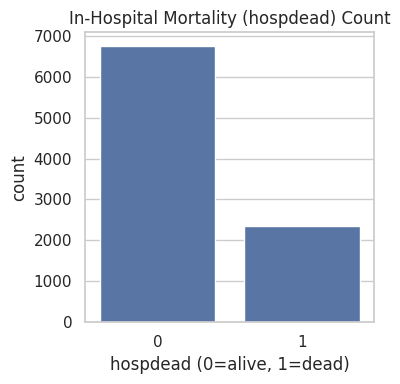

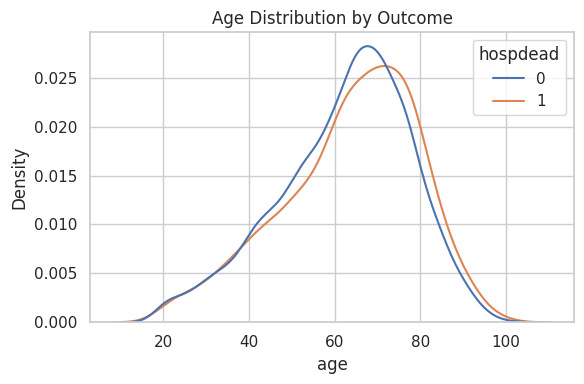

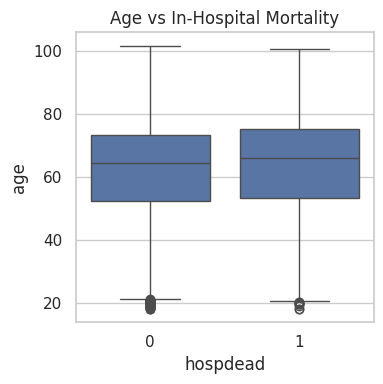

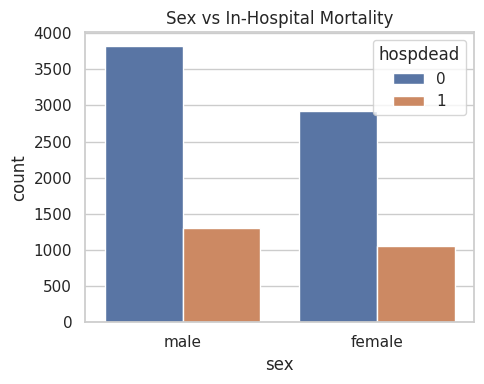

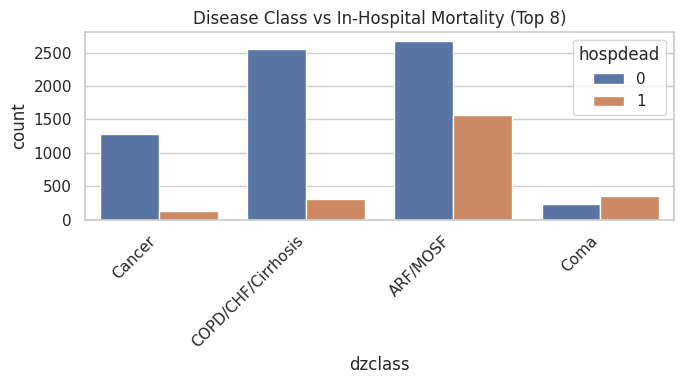

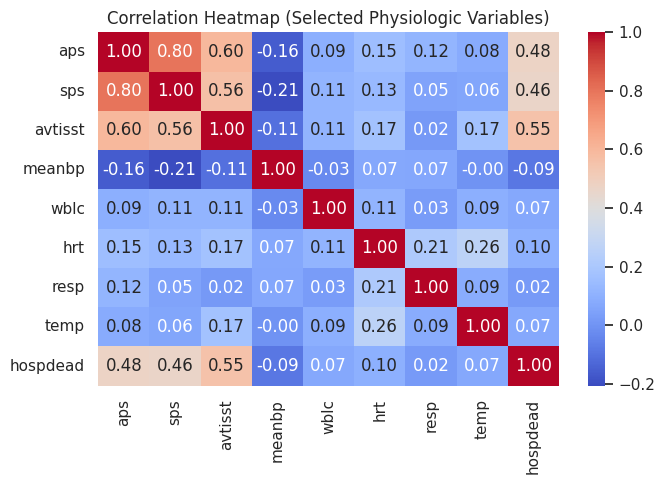

EDA complete.


In [8]:
# 1) Class balance
plt.figure(figsize=(4, 4))
sns.countplot(x=y)
plt.title('In-Hospital Mortality (hospdead) Count')
plt.xlabel('hospdead (0=alive, 1=dead)')
plt.tight_layout()
plt.show()

# 2) Age distribution by outcome
if 'age' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=df, x='age', hue=target_col, common_norm=False)
    plt.title('Age Distribution by Outcome')
    plt.tight_layout()
    plt.show()

# 3) Boxplot of age by outcome
if 'age' in df.columns:
    plt.figure(figsize=(4, 4))
    sns.boxplot(data=df, x=target_col, y='age')
    plt.title('Age vs In-Hospital Mortality')
    plt.tight_layout()
    plt.show()

# 4) Outcome vs sex
if 'sex' in df.columns:
    plt.figure(figsize=(5, 4))
    sns.countplot(data=df, x='sex', hue=target_col)
    plt.title('Sex vs In-Hospital Mortality')
    plt.tight_layout()
    plt.show()

# 5) Outcome vs dzclass (disease class) – top 8 categories
if 'dzclass' in df.columns:
    plt.figure(figsize=(7, 4))
    top_dz = df['dzclass'].value_counts().index[:8]
    sns.countplot(data=df[df['dzclass'].isin(top_dz)], x='dzclass', hue=target_col)
    plt.xticks(rotation=45, ha='right')
    plt.title('Disease Class vs In-Hospital Mortality (Top 8)')
    plt.tight_layout()
    plt.show()

# 6) Correlation heatmap for selected physiologic vars (if present)
corr_cols = [c for c in ['aps', 'sps', 'avtisst', 'meanbp', 'wblc', 'hrt', 'resp', 'temp'] if c in df.columns]
if corr_cols:
    corr = df[corr_cols + [target_col]].corr()
    plt.figure(figsize=(7, 5))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap (Selected Physiologic Variables)')
    plt.tight_layout()
    plt.show()

print('EDA complete.')

In [9]:
# Stratified 60/20/20 split based on the binary outcome

sss1 = StratifiedShuffleSplit(n_splits=1, train_size=0.6, random_state=42)
train_idx, temp_idx = next(sss1.split(X, y))

X_train = X.iloc[train_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)

X_temp = X.iloc[temp_idx].reset_index(drop=True)
y_temp = y.iloc[temp_idx].reset_index(drop=True)

# From temp, split 50/50 -> 20/20 overall
sss2 = StratifiedShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx_rel, test_idx_rel = next(sss2.split(X_temp, y_temp))

X_val = X_temp.iloc[val_idx_rel].reset_index(drop=True)
y_val = y_temp.iloc[val_idx_rel].reset_index(drop=True)

X_test = X_temp.iloc[test_idx_rel].reset_index(drop=True)
y_test = y_temp.iloc[test_idx_rel].reset_index(drop=True)

print('Train shape:', X_train.shape, 'Deaths rate:', y_train.mean())
print('Val shape:  ', X_val.shape,   'Deaths rate:', y_val.mean())
print('Test shape: ', X_test.shape,  'Deaths rate:', y_test.mean())

Train shape: (5463, 31) Deaths rate: 0.2591982427237781
Val shape:   (1821, 31) Deaths rate: 0.2591982427237781
Test shape:  (1821, 31) Deaths rate: 0.2591982427237781


In [10]:
# Numeric transformer: IterativeImputer with XGBRegressor + StandardScaler

numeric_imputer = IterativeImputer(
    estimator=XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),
    max_iter=10,
    initial_strategy='median',
    skip_complete=True,
    random_state=42
)

numeric_transformer = Pipeline(steps=[
    ('imputer', numeric_imputer),
    ('scaler', StandardScaler())
])

# Categorical transformer: most frequent + one-hot
if categorical_cols:
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
else:
    categorical_transformer = 'drop'

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print('Preprocessor defined.')

Preprocessor defined.


In [11]:
models = {}

# 1) Logistic Regression
models['logreg'] = (
    LogisticRegression(max_iter=1000, solver='lbfgs'),
    {
        'model__C': [0.01, 0.1, 1, 10],
        'model__class_weight': [None, 'balanced']
    }
)

# 2) Decision Tree
models['tree'] = (
    DecisionTreeClassifier(random_state=42),
    {
        'model__max_depth': [3, 5, 7, 9],
        'model__min_samples_leaf': [1, 5, 10],
        'model__max_features': ['sqrt', 'log2', None],
        'model__class_weight': [None, 'balanced']
    }
)

# 3) Random Forest
models['rf'] = (
    RandomForestClassifier(random_state=42),
    {
        'model__n_estimators': [100, 300],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_leaf': [1, 5, 10],
        'model__max_features': ['sqrt', 'log2'],
        'model__class_weight': ['balanced', 'balanced_subsample']
    }
)

# 4) Gradient Boosting (no class_weight; we will use sample_weight)
models['gb'] = (
    GradientBoostingClassifier(random_state=42),
    {
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__n_estimators': [100, 300],
        'model__max_depth': [2, 3],
    }
)

# 5) SVM with RBF kernel
models['svm'] = (
    SVC(kernel='rbf', probability=True),
    {
        'model__C': [0.1, 1, 10],
        'model__gamma': [0.01, 0.1, 1],
        'model__class_weight': [None, 'balanced']
    }
)

print("Models and hyperparameter grids defined.")

Models and hyperparameter grids defined.


In [12]:
# Stratified k-fold CV on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compute sample weights for training to handle imbalance
sample_weight_train = compute_sample_weight('balanced', y_train)

print('CV and sample weights ready.')
print('Example class weights:',
      {cls: w for cls, w in zip(np.unique(y_train),
                                compute_sample_weight('balanced', np.unique(y_train)))})

CV and sample weights ready.
Example class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}


In [13]:
best_models = {}
results = []

for name, (clf, param_grid) in models.items():
    print(f"\n=== Tuning model: {name} ===")

    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', clf)
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0
    )

    # Pass sample weights through to underlying estimator
    grid.fit(X_train, y_train, model__sample_weight=sample_weight_train)

    best_pipe = grid.best_estimator_
    best_models[name] = best_pipe

    # Validation performance
    if hasattr(best_pipe.named_steps['model'], 'predict_proba'):
        y_val_proba = best_pipe.predict_proba(X_val)[:, 1]
        y_test_proba = best_pipe.predict_proba(X_test)[:, 1]
    else:
        model_step = best_pipe.named_steps['model']
        if hasattr(model_step, 'decision_function'):
            y_val_scores = best_pipe.decision_function(X_val)
            y_test_scores = best_pipe.decision_function(X_test)
        else:
            y_val_scores = best_pipe.predict(X_val)
            y_test_scores = best_pipe.predict(X_test)
        y_val_proba = y_val_scores
        y_test_proba = y_test_scores

    val_auc = roc_auc_score(y_val, y_val_proba)
    test_auc = roc_auc_score(y_test, y_test_proba)

    results.append((name, val_auc, test_auc, grid.best_params_))

    print(f'Validation ROC-AUC for best {name}: {val_auc:.4f}')
    print(f'Test ROC-AUC for best {name}:        {test_auc:.4f}')
    print('Best params:', grid.best_params_)


=== Tuning model: logreg ===
Validation ROC-AUC for best logreg: 0.9124
Test ROC-AUC for best logreg:        0.9092
Best params: {'model__C': 0.1, 'model__class_weight': None}

=== Tuning model: tree ===
Validation ROC-AUC for best tree: 0.8893
Test ROC-AUC for best tree:        0.8897
Best params: {'model__class_weight': None, 'model__max_depth': 5, 'model__max_features': None, 'model__min_samples_leaf': 10}

=== Tuning model: rf ===
Validation ROC-AUC for best rf: 0.9121
Test ROC-AUC for best rf:        0.9139
Best params: {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 300}

=== Tuning model: gb ===
Validation ROC-AUC for best gb: 0.9181
Test ROC-AUC for best gb:        0.9160
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}

=== Tuning model: svm ===
Validation ROC-AUC for best svm: 0.9128
Test ROC-AUC for best svm:        0.9105
Best param

In [26]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("\n=== Full Metrics Summary for All Models ===\n")

all_results = []

for name, model in best_models.items():
    # Get prediction scores
    if hasattr(model.named_steps['model'], "predict_proba"):
        y_test_proba = model.predict_proba(X_test)[:, 1]
        y_test_pred = (y_test_proba >= 0.5).astype(int)
    else:
        # Fallback
        y_test_pred = model.predict(X_test)
        y_test_proba = y_test_pred

    # Compute metrics
    auc = roc_auc_score(y_test, y_test_proba)
    acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred)
    rec = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    all_results.append((name, auc, acc, prec, rec, f1))

    print(f"{name:6s} | "
          f"AUC={auc:.4f} | "
          f"ACC={acc:.4f} | "
          f"PREC={prec:.4f} | "
         f"REC={rec:.4f} | "
          f"F1={f1:.4f}")


=== Full Metrics Summary for All Models ===

logreg | AUC=0.9092 | ACC=0.8413 | PREC=0.6488 | REC=0.8453 | F1=0.7341
tree   | AUC=0.8897 | ACC=0.8331 | PREC=0.6511 | REC=0.7669 | F1=0.7043
rf     | AUC=0.9139 | ACC=0.8364 | PREC=0.6394 | REC=0.8453 | F1=0.7281
gb     | AUC=0.9160 | ACC=0.8440 | PREC=0.6626 | REC=0.8114 | F1=0.7295
svm    | AUC=0.9105 | ACC=0.8710 | PREC=0.7926 | REC=0.6801 | F1=0.7320


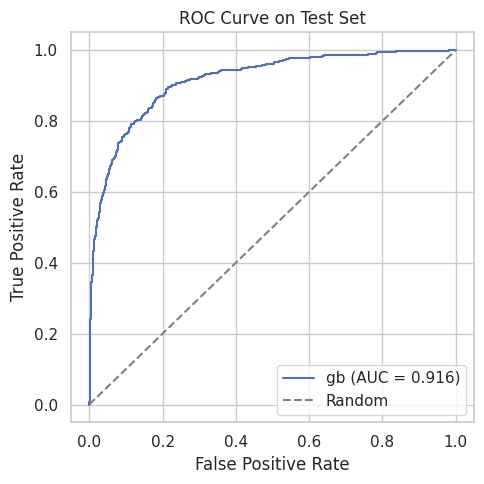

In [29]:
# Plot ROC curve on test set for the chosen best model
if hasattr(best_model.named_steps['model'], 'predict_proba'):
    y_test_proba_best = best_model.predict_proba(X_test)[:, 1]
else:
    model_step = best_model.named_steps['model']
    if hasattr(model_step, 'decision_function'):
        y_test_proba_best = best_model.decision_function(X_test)
    else:
        y_test_proba_best = best_model.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba_best)
auc_best = roc_auc_score(y_test, y_test_proba_best)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc_best:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [30]:
# Choose default threshold = 0.5 for classification
y_test_pred = (y_test_proba_best >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_test_pred)
print('Confusion Matrix (threshold=0.5):')
print(cm)

print('\nClassification Report:')
print(classification_report(y_test, y_test_pred, digits=3))

Confusion Matrix (threshold=0.5):
[[1154  195]
 [  89  383]]

Classification Report:
              precision    recall  f1-score   support

           0      0.928     0.855     0.890      1349
           1      0.663     0.811     0.730       472

    accuracy                          0.844      1821
   macro avg      0.796     0.833     0.810      1821
weighted avg      0.860     0.844     0.849      1821



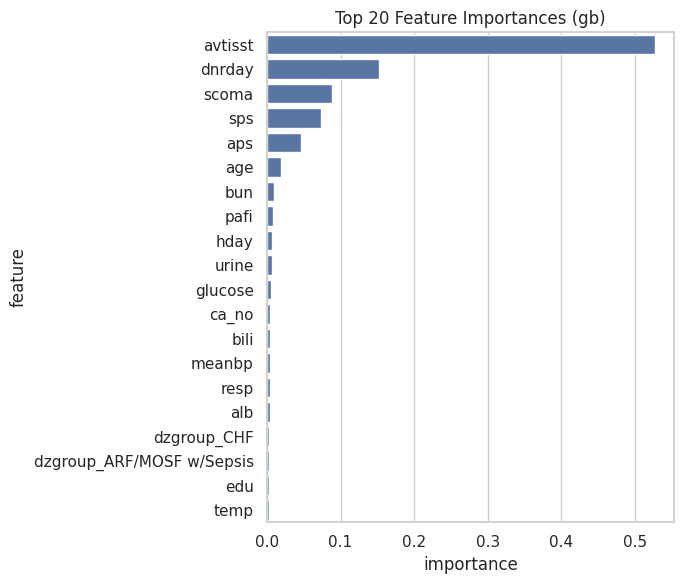

In [17]:
def get_feature_names(preprocessor, numeric_cols, categorical_cols):
    feature_names = []
    # numeric
    if 'num' in preprocessor.named_transformers_:
        feature_names.extend(numeric_cols)
    # categorical
    if categorical_cols and 'cat' in preprocessor.named_transformers_:
        ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
        cat_feature_names = ohe.get_feature_names_out(categorical_cols)
        feature_names.extend(cat_feature_names)
    return feature_names

pipe = best_model
prep = pipe.named_steps['preprocess']
clf = pipe.named_steps['model']

feature_names = get_feature_names(prep, numeric_cols, categorical_cols)

if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False).head(20)

    plt.figure(figsize=(7, 6))
    sns.barplot(data=imp_df, x='importance', y='feature')
    plt.title(f'Top 20 Feature Importances ({best_model_name})')
    plt.tight_layout()
    plt.show()

elif hasattr(clf, 'coef_'):
    coefs = clf.coef_.ravel()
    coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
    coef_df['abs_coef'] = coef_df['coef'].abs()
    coef_df = coef_df.sort_values('abs_coef', ascending=False).head(20)

    plt.figure(figsize=(7, 6))
    sns.barplot(data=coef_df, x='coef', y='feature')
    plt.title(f'Top 20 Coefficients ({best_model_name})')
    plt.tight_layout()
    plt.show()

else:
    print('Model does not expose feature_importances_ or coef_. '
          'Consider using permutation_importance or SHAP for deeper interpretation.')

=== SHAP Summary Plot ===


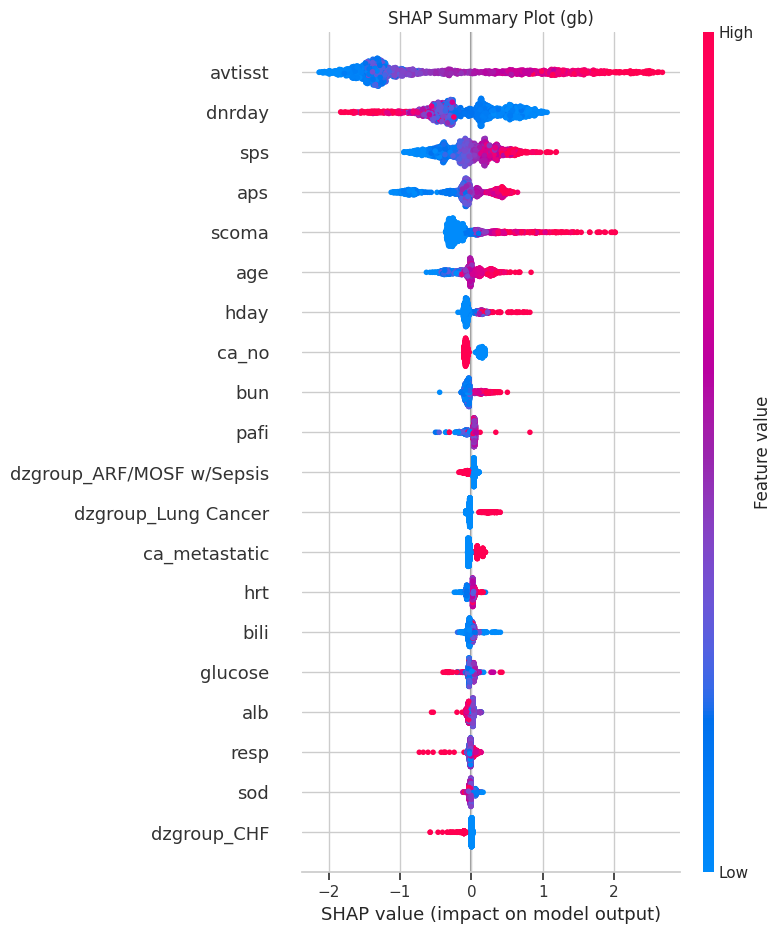

In [18]:
# Cell: SHAP Summary Plot (Tree-based models)

import shap

print("=== SHAP Summary Plot ===")

# Extract fitted estimator from pipeline
est = best_model.named_steps['model']

# Try tree explainer
explainer = shap.TreeExplainer(est)

# SHAP values for TEST set
# (we transform X_test through preprocessor)
X_test_trans = best_model.named_steps['preprocess'].transform(X_test)

shap_values = explainer.shap_values(X_test_trans)

# Plot summary
plt.title(f"SHAP Summary Plot ({best_model_name})")
shap.summary_plot(shap_values, X_test_trans, feature_names=feature_names)


Fraction of rows with ≥1 missing value: 0.8682042833607908

Top 10 most-missing features:
urine      0.533992
glucose    0.494234
bun        0.477979
alb        0.370346
income     0.327512
bili       0.285667
pafi       0.255354
ph         0.250851
edu        0.179462
wblc       0.023284
dtype: float64


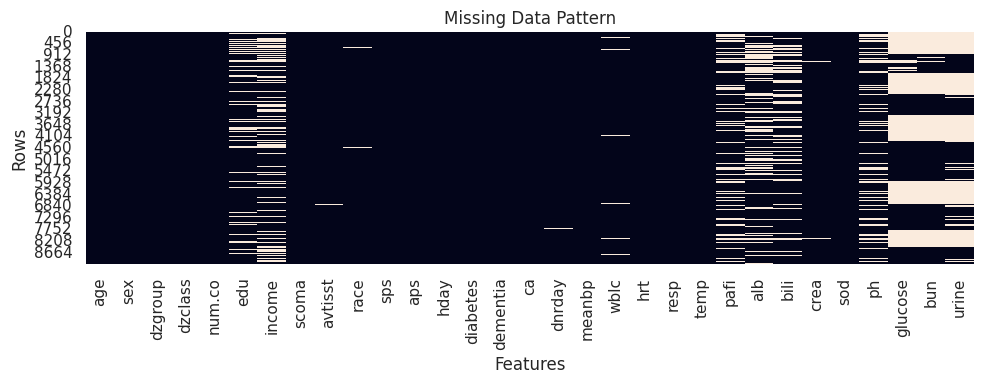

In [19]:
# Missingness analysis

print("Fraction of rows with ≥1 missing value:",
      (X.isna().sum(axis=1) > 0).mean())

missing_per_col = X.isna().mean().sort_values(ascending=False)

print("\nTop 10 most-missing features:")
print(missing_per_col.head(10))

plt.figure(figsize=(10, 4))
sns.heatmap(X.isna(), cbar=False)
plt.title("Missing Data Pattern")
plt.xlabel("Features")
plt.ylabel("Rows")
plt.tight_layout()
plt.savefig("missing_data_pattern.png", dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# Baseline model metrics: majority-class classifier

from sklearn.metrics import accuracy_score, f1_score

majority_class = y_train.value_counts().idxmax()
y_baseline = np.full_like(y_test, fill_value=majority_class)

baseline_acc = accuracy_score(y_test, y_baseline)
baseline_f1 = f1_score(y_test, y_baseline)

print(f"Majority class: {majority_class}")
print(f"Baseline Accuracy: {baseline_acc:.3f}")
print(f"Baseline F1: {baseline_f1:.3f}")
print("Baseline AUC is 0.50 for a random classifier.")

Majority class: 0
Baseline Accuracy: 0.741
Baseline F1: 0.000
Baseline AUC is 0.50 for a random classifier.


In [21]:
# Uncertainty of ROC-AUC across repeated stratified splits

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline

auc_scores = []

sss = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

for split_idx, (train_idx, test_idx) in enumerate(sss.split(X, y), start=1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # Recreate the same model class with best hyperparameters
    base_model = best_model.named_steps['model'].__class__(**best_model.named_steps['model'].get_params())

    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', base_model)
    ])

    pipe.fit(X_tr, y_tr)
    y_te_proba = pipe.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, y_te_proba)
    auc_scores.append(auc)
    print(f"Split {split_idx}: AUC = {auc:.3f}")

auc_mean = np.mean(auc_scores)
auc_std = np.std(auc_scores)

print("\nRepeated-split ROC-AUC: {:.3f} ± {:.3f}".format(auc_mean, auc_std))

Split 1: AUC = 0.930
Split 2: AUC = 0.916
Split 3: AUC = 0.914
Split 4: AUC = 0.917
Split 5: AUC = 0.910
Split 6: AUC = 0.907
Split 7: AUC = 0.922
Split 8: AUC = 0.922
Split 9: AUC = 0.916
Split 10: AUC = 0.908

Repeated-split ROC-AUC: 0.916 ± 0.007


Length of X_val.columns: 31
Length of result_perm.importances_mean: 31
Top 15 features by permutation importance:


,feature,importance_mean,importance_std
8,avtisst,0.171465,0.012008
16,dnrday,0.041544,0.002530
7,scoma,0.026189,0.002756
10,sps,0.015879,0.001938
11,aps,0.008495,0.001161
0,age,0.006082,0.000755
2,dzgroup,0.004041,0.001229
15,ca,0.003252,0.000638
12,hday,0.002144,0.001049
29,bun,0.000975,0.000388


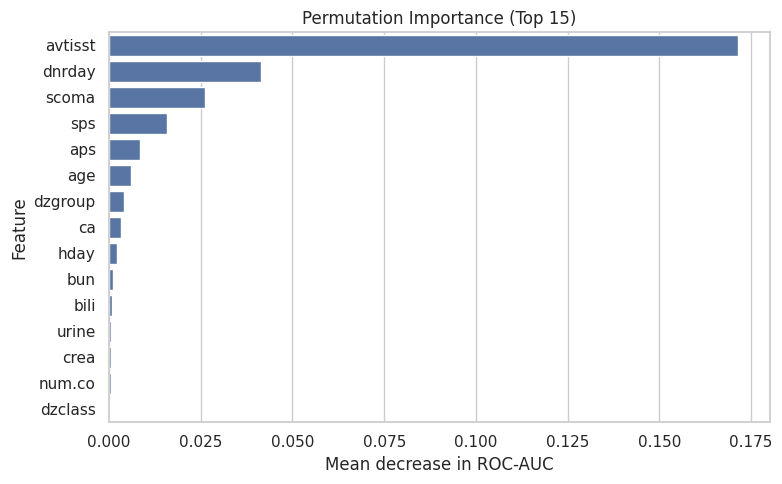

In [22]:
# Global feature importance via permutation importance (validation set)

from sklearn.inspection import permutation_importance

result_perm = permutation_importance(
    best_model,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

# The permutation_importance function calculates importance based on the original input features.
# Therefore, we should use the original column names from X_val, not the processed feature names.
# If you needed importance on processed features, you'd transform X_val first and apply the model directly.

print(f"Length of X_val.columns: {len(X_val.columns)}")
print(f"Length of result_perm.importances_mean: {len(result_perm.importances_mean)}")

perm_df = pd.DataFrame({
    "feature": X_val.columns.tolist(), # Use original feature names from X_val
    "importance_mean": result_perm.importances_mean,
    "importance_std": result_perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("Top 15 features by permutation importance:")
display(perm_df.head(15))

plt.figure(figsize=(8, 5))
sns.barplot(
    data=perm_df.head(15),
    x="importance_mean",
    y="feature"
)
plt.xlabel("Mean decrease in ROC-AUC")
plt.ylabel("Feature")
plt.title("Permutation Importance (Top 15)")
plt.tight_layout()
plt.savefig("permutation_importance_top15.png", dpi=300, bbox_inches='tight')
plt.show()

Top 15 features by mean |SHAP|:


,feature,mean_abs_shap
4,avtisst,1.225489
10,dnrday,0.475288
5,sps,0.292652
6,aps,0.288323
3,scoma,0.283620
0,age,0.161735
7,hday,0.097041
49,ca_no,0.092101
23,bun,0.082344
16,pafi,0.054169


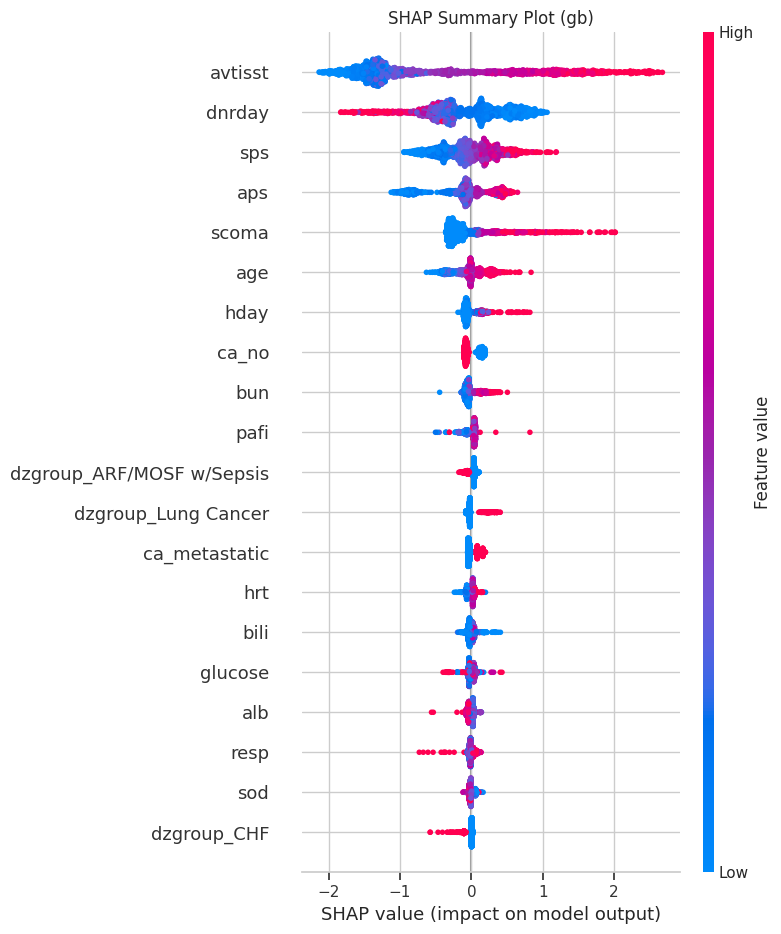

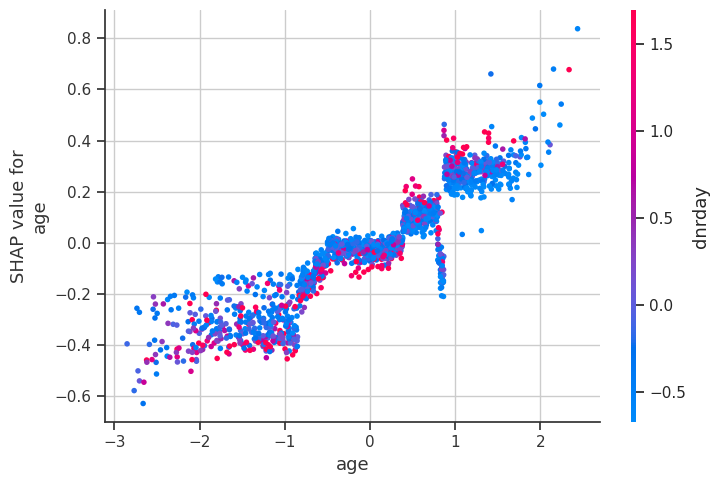

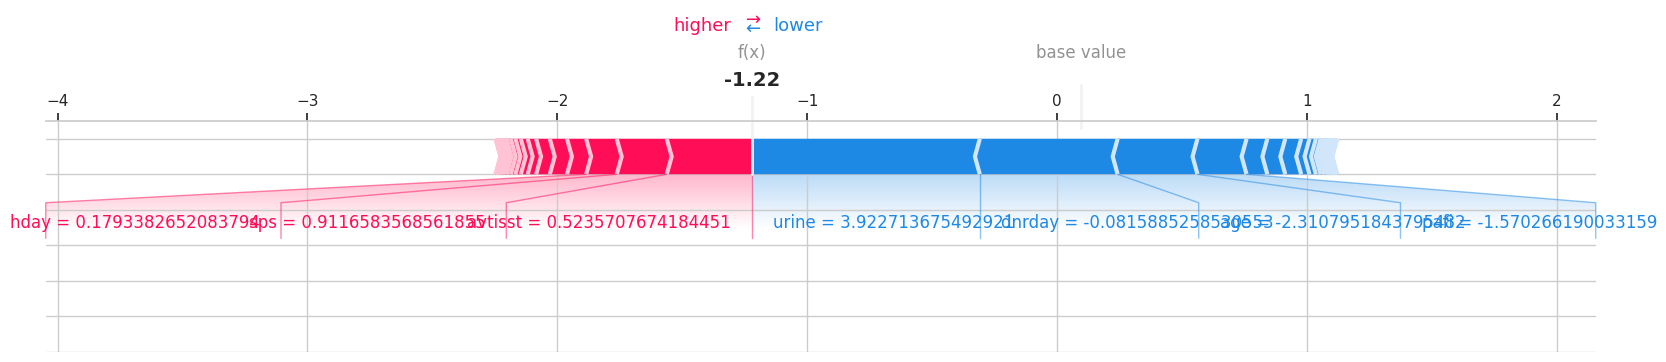

<Figure size 640x480 with 0 Axes>

In [23]:
# Additional SHAP analyses: global table, dependence plot, local force plot

import shap
shap.initjs()

# We assume SHAP summary cell defined:
# - shap_values
# - X_test_trans
# - feature_names
# - explainer

# Handle binary vs other outputs
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_values_plot = shap_values

# Global importance table: mean |SHAP| per feature
shap_abs = np.abs(shap_values_plot).mean(axis=0)
shap_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": shap_abs
}).sort_values("mean_abs_shap", ascending=False)

print("Top 15 features by mean |SHAP|:")
display(shap_df.head(15))

# Save SHAP summary beeswarm at 300 dpi
plt.title(f"SHAP Summary Plot ({best_model_name})")
shap.summary_plot(shap_values_plot, X_test_trans, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig("shap_summary_beeswarm.png", dpi=300, bbox_inches='tight')
plt.show()

# Dependence plot for an important feature, e.g., 'age' if present
if "age" in feature_names:
    shap.dependence_plot("age", shap_values_plot, X_test_trans, feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.savefig("shap_dependence_age.png", dpi=300, bbox_inches='tight')
    plt.show()

# Local force plot for first test sample
idx = 0
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1] if len(base_value) > 1 else base_value[0]

shap.force_plot(
    base_value,
    shap_values_plot[idx, :],
    X_test_trans[idx, :],
    feature_names=feature_names,
    matplotlib=True
)
plt.tight_layout()
plt.savefig("shap_force_plot_idx0.png", dpi=300, bbox_inches='tight')
plt.show()

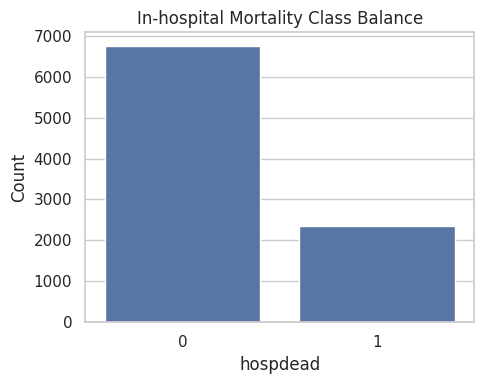

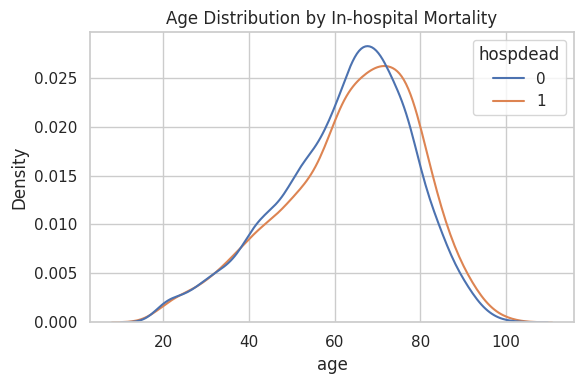

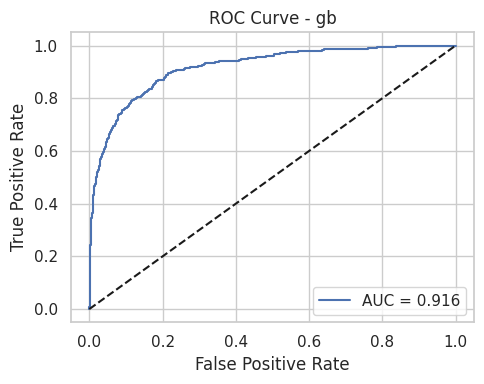

In [24]:
# High-resolution versions of key plots (300 dpi)

# 1) Class balance
plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("In-hospital Mortality Class Balance")
plt.xlabel("hospdead")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("eda_class_balance.png", dpi=300, bbox_inches='tight')
plt.show()

# 2) Age distribution by outcome (if 'age' in df)
if 'age' in df.columns:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x='age', hue=target_col, common_norm=False)
    plt.title("Age Distribution by In-hospital Mortality")
    plt.tight_layout()
    plt.savefig("eda_age_by_outcome.png", dpi=300, bbox_inches='tight')
    plt.show()

# 3) ROC curve for best model on TEST set (recompute if needed)
from sklearn.metrics import roc_curve, roc_auc_score

y_test_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_test:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name}")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_test.png", dpi=300, bbox_inches='tight')
plt.show()